In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import cv2
import matplotlib.pyplot as plt


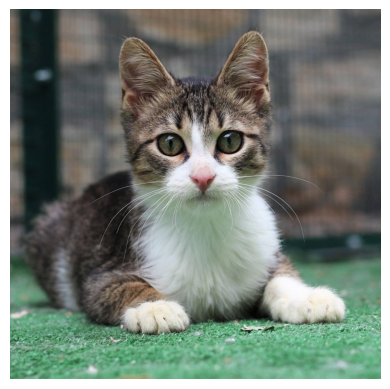

In [ ]:
original_path = '/content/drive/MyDrive/Image_Augmentation/original/cat.jpg'
image = cv2.imread(original_path)
image = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
plt.imshow(image)
plt.axis("off")
plt.show()

In [ ]:
print(image.shape)

(719, 720, 3)


In [ ]:
resized = cv2.resize(image,(128,128))
resized.shape

(128, 128, 3)

AxesImage(shape=(128, 128, 3))


(np.float64(-0.5), np.float64(127.5), np.float64(127.5), np.float64(-0.5))

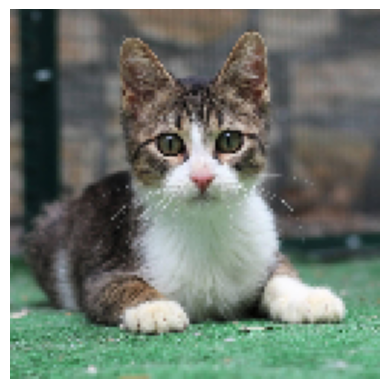

In [ ]:
print(plt.imshow(resized))
plt.axis("off")

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
            rotation_range = 40,
            zoom_range = 0.2,
            horizontal_flip = True

)

In [ ]:
X = resized.reshape((1,)+resized.shape)
X.shape

(1, 128, 128, 3)

In [ ]:
new_image = next(datagen.flow(X,batch_size = 1))

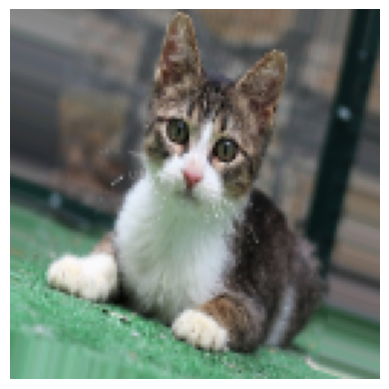

In [ ]:
plt.imshow(new_image[0].astype("uint8")) #uint8  - unsigned signed bit 8 integer
plt.axis('off')
plt.show()

In [ ]:
output_path = '/content/drive/MyDrive/Image_Augmentation/augmented/cat_augmented.jpg'
cv2.imwrite(output_path,
            cv2.cvtColor(new_image[0].astype("uint8"), cv2.COLOR_RGB2BGR))

True

In [ ]:
data = ImageDataGenerator(
    rotation_range=40,
    width_shift_range=0.3,
    height_shift_range=0.3,
    zoom_range=0.4,
    shear_range=20,
    horizontal_flip=True
)

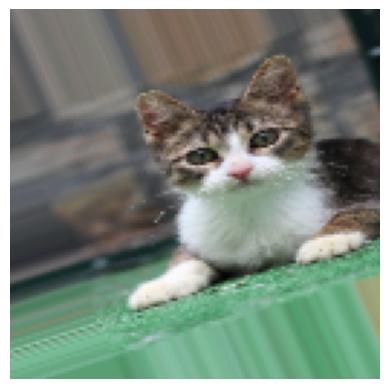

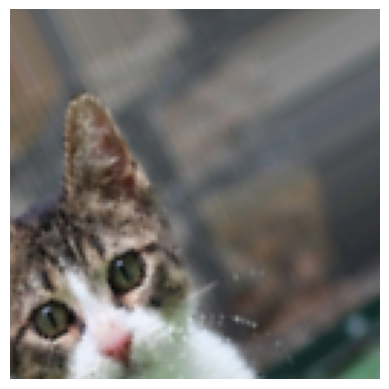

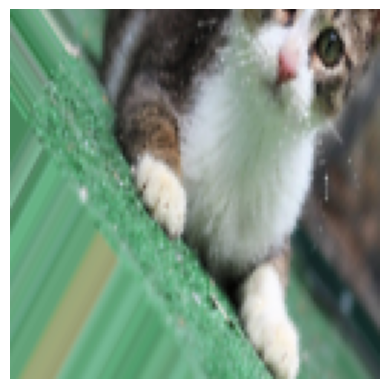

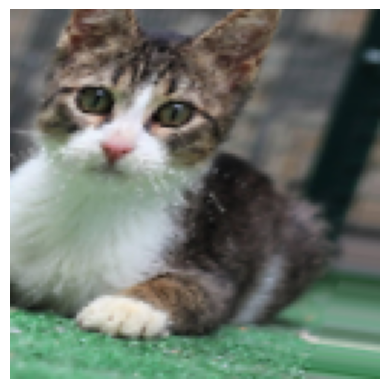

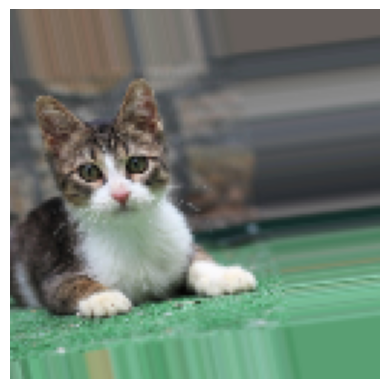

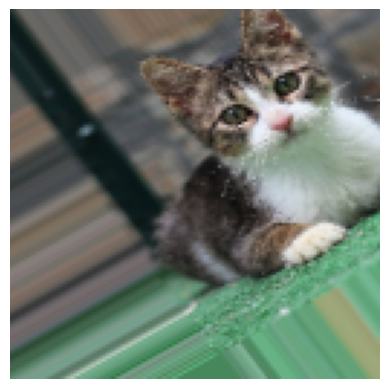

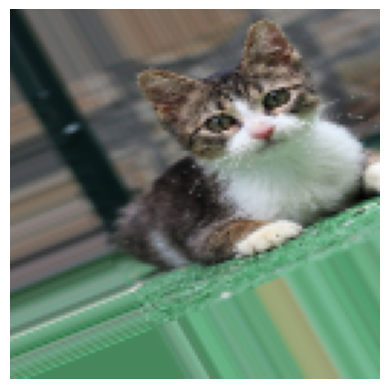

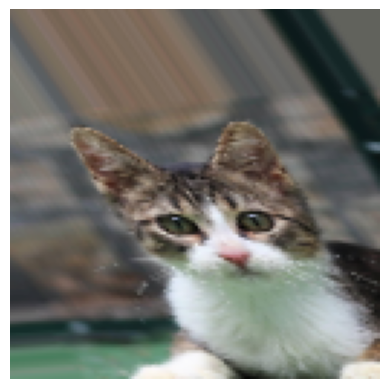

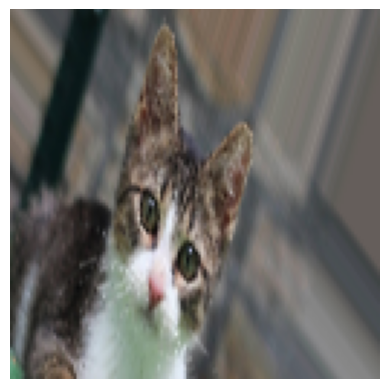

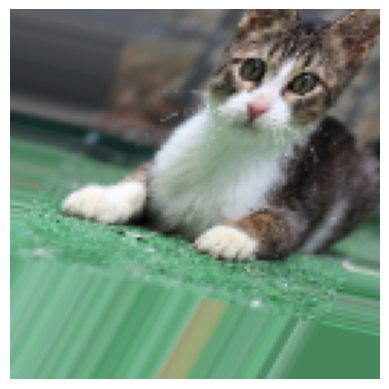

saved


In [ ]:
save_path = '/content/drive/MyDrive/Image_Augmentation/augmented'
genrator = data.flow(X,batch_size = 1,save_to_dir = save_path,save_prefix = "new_aug",save_format = "jpg")


for i in range(10):
  new = next(genrator)

  plt.imshow(new[0].astype("uint8"))
  plt.axis("off")
  plt.show()

print("saved")

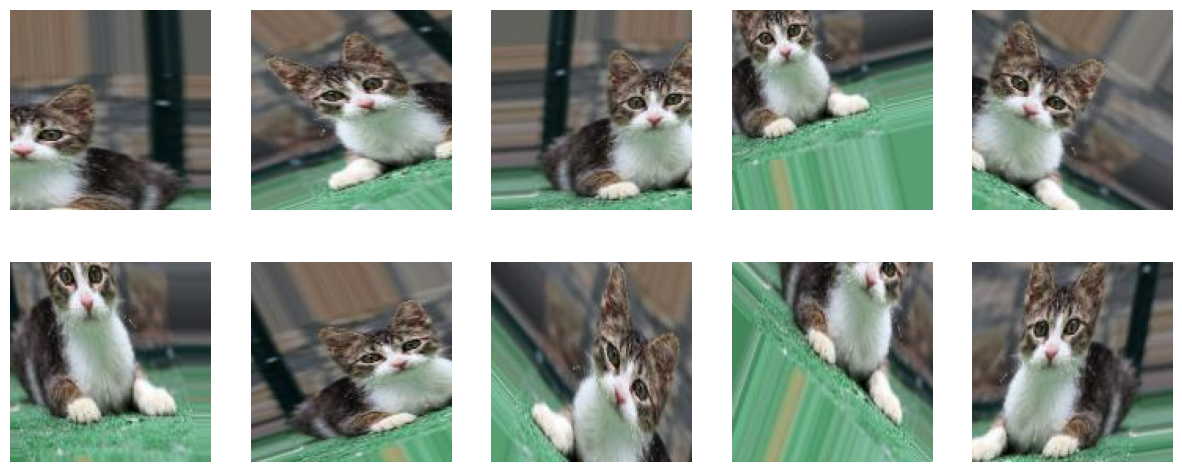

In [ ]:
import glob
import cv2
import matplotlib.pyplot as plt

files = glob.glob(
    '/content/drive/MyDrive/Image_Augmentation/augmented/new_aug*.jpg'
)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for ax, file in zip(axes.ravel(), files[:10]):
    img = cv2.cvtColor(cv2.imread(file), cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.axis('off')

plt.show()

In [ ]:
for i in range(len(files)):
  print(files[i])


/content/drive/MyDrive/Image_Augmentation/augmented/new_aug_0_5289.jpg
/content/drive/MyDrive/Image_Augmentation/augmented/new_aug_0_3442.jpg
/content/drive/MyDrive/Image_Augmentation/augmented/new_aug_0_3493.jpg
/content/drive/MyDrive/Image_Augmentation/augmented/new_aug_0_8130.jpg
/content/drive/MyDrive/Image_Augmentation/augmented/new_aug_0_36.jpg
/content/drive/MyDrive/Image_Augmentation/augmented/new_aug_0_398.jpg
/content/drive/MyDrive/Image_Augmentation/augmented/new_aug_0_7267.jpg
/content/drive/MyDrive/Image_Augmentation/augmented/new_aug_0_807.jpg
/content/drive/MyDrive/Image_Augmentation/augmented/new_aug_0_7077.jpg
/content/drive/MyDrive/Image_Augmentation/augmented/new_aug_0_7871.jpg
/content/drive/MyDrive/Image_Augmentation/augmented/new_aug_0_9014.jpg
/content/drive/MyDrive/Image_Augmentation/augmented/new_aug_0_4877.jpg
/content/drive/MyDrive/Image_Augmentation/augmented/new_aug_0_4766.jpg
/content/drive/MyDrive/Image_Augmentation/augmented/new_aug_0_6148.jpg
/content/d

In [ ]:
import glob

files = glob.glob(
    '/content/drive/MyDrive/Image_Augmentation/original/*'
)

print(len(files))

10


In [ ]:
resized_img = []
for i in range(len(files)):
  image = cv2.imread(files[i])
  resize = cv2.resize(image,(128,128))
  resized_img.append(resize)





In [ ]:
import numpy as np

image_batch = np.array(resized_img)


print(image_batch.shape)

(10, 128, 128, 3)


In [ ]:
image_batch = image_batch / 255.0

In [ ]:
print(image_batch.min())
print(image_batch.max())

0.0
1.0


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)



In [ ]:
generator = datagen.flow(
    image_batch,
    batch_size=10,
    save_to_dir='/content/drive/MyDrive/Image_Augmentation/augmented',
    save_prefix='cat',
    save_format='jpg'
)

next(generator)

array([[[[3.06514800e-01, 2.92388827e-01, 2.73877382e-01],
         [3.02483708e-01, 2.95076251e-01, 2.77908474e-01],
         [2.98452616e-01, 2.97763646e-01, 2.81939566e-01],
         ...,
         [3.99505198e-01, 4.32510227e-01, 4.80979502e-01],
         [3.72648835e-01, 3.98444086e-01, 4.20418113e-01],
         [2.79041439e-01, 2.98067480e-01, 2.89431065e-01]],

        [[3.09803933e-01, 2.83519387e-01, 2.72813827e-01],
         [3.09803933e-01, 2.87550479e-01, 2.71470129e-01],
         [3.08418423e-01, 2.91119754e-01, 2.71973759e-01],
         ...,
         [3.95052940e-01, 4.33410496e-01, 4.95964527e-01],
         [3.48423839e-01, 3.69113624e-01, 3.91006559e-01],
         [2.35017940e-01, 2.58189172e-01, 2.48467013e-01]],

        [[3.00048262e-01, 2.75179505e-01, 2.69631982e-01],
         [3.08110476e-01, 2.77866900e-01, 2.73663074e-01],
         [3.09803933e-01, 2.81615764e-01, 2.73448348e-01],
         ...,
         [3.75713557e-01, 4.22929913e-01, 4.86441225e-01],
         [

In [ ]:
print("Image batch shape:", image_batch.shape)

Image batch shape: (10, 128, 128, 3)


In [ ]:
print(image_batch.dtype)
print(image_batch.min(), image_batch.max())

float64
0.0 1.0
